### Set Up

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
from functools import reduce
import os
import sys

/Users/anna/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/anna/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Automatically reload modules when they change
%load_ext autoreload
%autoreload 2

In [3]:
scenarios_path = Path().resolve() / "../../scenarios_inputs" / "cheung_variants" 
annotated_output_path = Path().resolve() / "../../annotated_outputs" / "cheung_variants"
plots_path = Path().resolve() / "../../analysis" / "cheung_variants" / "cheung_visualizations"
print(f"scenarios_path: {scenarios_path}")
print(f"annotated_output_path: {annotated_output_path}")



scenarios_path: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../scenarios_inputs/cheung_variants
annotated_output_path: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants


In [4]:
ROOT_DIR = os.getcwd() + '/../../'
sys.path.append(ROOT_DIR)
sys.path.append(ROOT_DIR+'src/')


In [5]:
ROOT_DIR

'/Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../'

In [6]:
import analysis_utils
import src.generic_analysis_utils as generic_analysis_utils

### Define Functions

In [12]:
def read_scenario(file_path): 

    narrative, id = generic_analysis_utils.parse_filename_cheung(file_path)


    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    nodes = [json.loads(line.strip()) for line in lines if line.strip()]

    act_choice = generic_analysis_utils.extract_action(nodes)


    # also return original scenario text for reference
    with open(scenarios_path / f"{narrative}.json") as f:

        scenario_list = json.load(f)
        #get the one with the matching id
        this_scenario = next(s for s in scenario_list if s['id'] == id)
     

        #extract the condition from the json read in
        scenario_text = this_scenario['text']
        scenario_deontology = this_scenario['deontology_level']
        scenario_utility = this_scenario['utility_level']
        
    #create a little dictionary with everything in it
    scenario_info = {
        "narrative": narrative,
        "id": id,
        "act": act_choice,
        "text": scenario_text,
        "deontology": scenario_deontology,
        "utility": scenario_utility
    }

    return nodes, scenario_info

In [13]:
def single_scenario_analysis(scenario_name, this_id, act_id):

    filename = filename_template % (scenario_name, this_id, act_id)

    file_path = annotated_output_path / filename


    nodes, scenario_dictionary = read_scenario(file_path)
    
    print(f"Read scenario: {file_path}")

    print(f"Scenario number: {scenario_dictionary['id']}")
    print(f"Scenario action choice: {scenario_dictionary['act']}")
    print(f"Scenario utility: {scenario_dictionary['utility']}")
    print(f"Scenario deontology: {scenario_dictionary['deontology']}")
    util_df =  generic_analysis_utils.events_to_utility_df(nodes)


    #get the column means for the utility dataframe (per entity)
    print(util_df.mean())

    util_mean = np.mean(util_df.mean())
    print('overall mean: ' + str(util_mean))

    return util_mean

In [14]:
def get_counterfact_util(scenario_id):

    util_mean_1 = single_scenario_analysis(SCENARIO_NAME, scenario_id,1)
    print('\n\n')
    util_mean_2 = single_scenario_analysis(SCENARIO_NAME, scenario_id,2)

    util_diff = util_mean_1 -  util_mean_2
    print('\n\nutility difference between choice 1 and choice 2: ' + str(util_diff))

    return util_diff


In [15]:
def create_agg_df():

    rows = []

    for scenario_id in SCENARIO_LIST:


            #read in scenario action choice 1
            this_filename = filename_template % (SCENARIO_NAME, scenario_id, 1)
            file_path = annotated_output_path / this_filename
            nodes, scenario_dictionary = read_scenario(file_path)


            # #get condition labels
            # print(f"Scenario number: {scenario_dictionary['id']}")
            # print(f"Scenario action choice: {scenario_dictionary['act']}")
            # print(f"Scenario utility: {scenario_dictionary['utility']}")
            # print(f"Scenario deontology: {scenario_dictionary['deontology']}")


            #get utility from this action
            util_df =  generic_analysis_utils.events_to_utility_df(nodes)
            util_mean_1 = np.mean(util_df.mean())

            #read in scenario action choice 2
            this_filename = filename_template % (SCENARIO_NAME, scenario_id, 2)
            file_path = annotated_output_path / this_filename
            nodes_2, scenario_dictionary_2 = read_scenario(file_path)
            #get utility from this action
            util_df =  generic_analysis_utils.events_to_utility_df(nodes_2)
            util_mean_2 = np.mean(util_df.mean())


            util_diff = util_mean_1 -  util_mean_2



            rows.append(
                {
                    "scenario_id": scenario_dictionary.get("id"),
                    "narrative": scenario_dictionary.get("narrative"),
                    "deontology_label": scenario_dictionary.get("deontology"),
                    "utility_label": scenario_dictionary.get("utility"),
                    "deontology_rating": generic_analysis_utils.extract_deontology(nodes),
                    "utility_rating": util_diff,        
                }
            )

    results_df = pd.DataFrame(rows)
    results_df.sort_values(by="scenario_id", inplace=True)
    # Ensure numeric columns are numeric
    results_df["deontology_rating"] = pd.to_numeric(results_df["deontology_rating"], errors="coerce")
    results_df["utility_rating"] = pd.to_numeric(results_df["utility_rating"], errors="coerce")

    return results_df

### Select scenario to analyze

In [72]:
#get all of the json files in the annotated_output_path
SCENARIO_NAME = "lifeboat"
json_files = list(annotated_output_path.glob(f"*{SCENARIO_NAME}_*choice_1.json"))
SCENARIO_LIST = list(range(1, int(len(json_files)) + 1))
#note, we assume that there are 2 action ids, where id 1 is the action and id 2 is the counterfactual action. 
filename_template = "%s_%d_choice_%d.json"

### Extract utility and deontology scores from individual scanerios to examine them closely

In [78]:
get_counterfact_util(1)

Read scenario: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/lifeboat_1_choice_1.json
Scenario number: 1
Scenario action choice: physically throw 10 passengers from lifeboat B overboard
Scenario utility: 3
Scenario deontology: 1
i                                                            -1.428571
the other occupants of lifeboat a                           -18.571429
10 passengers in lifeboat b who would be thrown overboard   -63.571429
51 remaining occupants of lifeboat b                          1.857143
dtype: float64
overall mean: -20.428571428571427



Read scenario: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/lifeboat_1_choice_2.json
Scenario number: 1
Scenario action choice: do nothing
Scenario utility: 3
Scenario deontology: 1
i, the captain in lifeboat a                          -14.50
the other crew members and passengers in lifeboat a     1.25
61 passeng

0.508928571428573

In [82]:
get_counterfact_util(4)

Read scenario: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/lifeboat_4_choice_1.json
Scenario number: 4
Scenario action choice: physically throw 10 passengers from lifeboat B overboard
Scenario utility: 2
Scenario deontology: 1
i, the captain in lifeboat a                                                   -23.857143
several other crew members and passengers in lifeboat a                        -12.142857
10 adult passengers in lifeboat b who would be physically thrown overboard     -26.428571
51 remaining passengers and crew members in lifeboat b who would stay aboard    16.714286
i                                                                               -0.714286
dtype: float64
overall mean: -9.285714285714286



Read scenario: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/lifeboat_4_choice_2.json
Scenario number: 4
Scenario action choice: do nothing
Scenario u

24.54761904761905

In [81]:
get_counterfact_util(7)

Read scenario: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/lifeboat_7_choice_1.json
Scenario number: 7
Scenario action choice: physically throw 10 passengers from lifeboat B overboard
Scenario utility: 1
Scenario deontology: 1
i                                                            5.714286
other occupants of lifeboat a                                6.857143
10 occupants of lifeboat b who would be thrown overboard    -6.571429
51 occupants of lifeboat b who would remain in the boat     26.571429
dtype: float64
overall mean: 8.142857142857142



Read scenario: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/lifeboat_7_choice_2.json
Scenario number: 7
Scenario action choice: do nothing
Scenario utility: 1
Scenario deontology: 1
i                               -42.5
other occupants of lifeboat a   -20.0
61 occupants of lifeboat b      -56.5
dtype: float64
overall m

47.80952380952381

In [83]:
get_counterfact_util(2)

Read scenario: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/lifeboat_2_choice_1.json
Scenario number: 2
Scenario action choice: remove the barrier protecting 10 passengers from falling overboard
Scenario utility: 3
Scenario deontology: 2
i                                                                                                 20.0
several other crew members and passengers in lifeboat a                                          -24.6
10 passengers in lifeboat b who are currently being kept from falling overboard by the barrier   -59.0
51 other passengers and crew members in lifeboat b                                                 1.6
dtype: float64
overall mean: -15.5



Read scenario: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/lifeboat_2_choice_2.json
Scenario number: 2
Scenario action choice: do nothing
Scenario utility: 3
Scenario deontology: 2
i       

48.08333333333334

In [84]:
get_counterfact_util(5)

Read scenario: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/lifeboat_5_choice_1.json
Scenario number: 5
Scenario action choice: remove the barrier protecting 10 passengers from falling overboard
Scenario utility: 2
Scenario deontology: 2
i, the captain in lifeboat a                                                             -15.500000
other crew members and passengers in lifeboat a                                          -14.666667
10 passengers currently being kept from falling overboard by the barrier on lifeboat b   -10.000000
51 other passengers and crew members in lifeboat b                                        16.666667
i                                                                                         15.833333
dtype: float64
overall mean: -1.5333333333333325



Read scenario: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/lifeboat_5_choice_2.json
Sce

48.46666666666666

In [85]:
get_counterfact_util(8)

Read scenario: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/lifeboat_8_choice_1.json
Scenario number: 8
Scenario action choice: remove the barrier protecting 10 passengers from falling overboard
Scenario utility: 1
Scenario deontology: 2
i                                                                                         10.833333
an unknown number of other crew members and passengers in lifeboat a                      -0.833333
10 passengers in lifeboat b currently being kept from falling overboard by the barrier    -1.666667
51 other passengers and crew members in lifeboat b                                        12.166667
dtype: float64
overall mean: 5.125



Read scenario: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants/lifeboat_8_choice_2.json
Scenario number: 8
Scenario action choice: do nothing
Scenario utility: 1
Scenario deontology: 2
i                   

19.125

In [ ]:
get_counterfact_util(9)

In [ ]:
get_counterfact_util(6)

In [ ]:
get_counterfact_util(3)

### Get aggregate utilities and arrange into dataframe

In [73]:
results_df = create_agg_df()
results_df.sort_values(by="deontology_label", inplace=True)
results_df

,scenario_id,narrative,deontology_label,utility_label,deontology_rating,utility_rating
0,1,lifeboat,1,3,-61.0,0.508929
3,4,lifeboat,1,2,-61.0,24.547619
6,7,lifeboat,1,1,-61.0,47.809524
1,2,lifeboat,2,3,-59.0,48.083333
4,5,lifeboat,2,2,-59.0,48.466667
7,8,lifeboat,2,1,-59.0,19.125000
2,3,lifeboat,3,3,-37.0,22.938889
5,6,lifeboat,3,2,-37.0,14.703704
8,9,lifeboat,3,1,-37.0,-7.190476


In [74]:
# 1) Means/SEs by deontology_label (for both dependent measures)
summary_by_deontology = (
    results_df
    .groupby("deontology_label", dropna=False)
    .agg(
        n=("deontology_rating", "count"),
        deontology_rating_mean=("deontology_rating", "mean"),
        deontology_rating_se=("deontology_rating", "sem"),
        utility_rating_mean=("utility_rating", "mean"),
        utility_rating_se=("utility_rating", "sem"),
    )
    .reset_index()
    .sort_values("deontology_label")
)

# 2) Means/SEs by utility_label (for both dependent measures)
summary_by_utility = (
    results_df
    .groupby("utility_label", dropna=False)
    .agg(
        n=("deontology_rating", "count"),
        deontology_rating_mean=("deontology_rating", "mean"),
        deontology_rating_se=("deontology_rating", "sem"),
        utility_rating_mean=("utility_rating", "mean"),
        utility_rating_se=("utility_rating", "sem"),
    )
    .reset_index()
    .sort_values("utility_label")
)


In [86]:
summary_by_deontology

,deontology_label,n,deontology_rating_mean,deontology_rating_se,utility_rating_mean,utility_rating_se
0,1,3,-61.0,0.0,24.288690,13.655119
1,2,3,-59.0,0.0,38.558333,9.717297
2,3,3,-37.0,0.0,10.150705,8.990588


In [87]:
summary_by_utility

,utility_label,n,deontology_rating_mean,deontology_rating_se,utility_rating_mean,utility_rating_se
0,1,3,-52.333333,7.688375,19.914683,15.882041
1,2,3,-52.333333,7.688375,29.239330,10.024861
2,3,3,-52.333333,7.688375,23.843717,13.740997


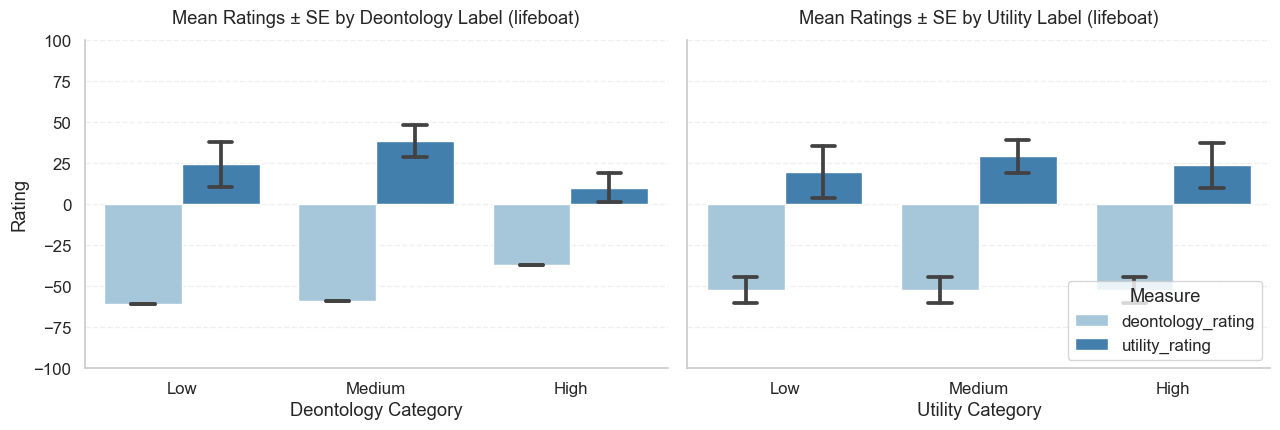

In [88]:
## get plot

# Long format for plotting both dependent measures together
plot_df = results_df.melt(
    id_vars=["deontology_label", "utility_label"],
    value_vars=["deontology_rating", "utility_rating"],
    var_name="measure",
    value_name="value",
)


# Ensure label columns are ordered numerically for plotting
deontology_order = sorted(plot_df["deontology_label"].dropna().astype(int).unique())
utility_order = sorted(plot_df["utility_label"].dropna().astype(int).unique())

plot_df["deontology_label"] = pd.Categorical(
    plot_df["deontology_label"].astype(int),
    categories=deontology_order,
    ordered=True
)
plot_df["utility_label"] = pd.Categorical(
    plot_df["utility_label"].astype(int),
    categories=utility_order,
    ordered=True
)
analysis_utils.make_deont_util_plot(SCENARIO_NAME, plot_df, plots_path)